In [43]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import cv2

In [31]:
image = Image.open('./data/Lenna.png').convert('L')  # Grayscale로 변환
image_array = np.array(image)

In [40]:
# 필터 정의
horizontal_filter = np.array([[-1, -1, -1],
                               [ 0,  0,  0],
                               [ 1,  1,  1]])

vertical_filter = np.array([[-1,  0,  1],
                             [-1,  0,  1],
                             [-1,  0,  1]])

diagonal_filter = np.array([[-1,  -1,  0],
                             [-1,  0,  1],
                             [0,  1,  1]])


# Convolution 연산 함수
def apply_filter(image, kernel):
    # 결과 저장을 위한 배열 초기화
    filtered_image = np.zeros_like(image)
    height, width = image.shape
    k = kernel.shape[0] // 2  # 필터의 중심 계산 (예: 3x3 필터 -> 1)

    for i in range(k, height - k):
        for j in range(k, width - k):
            region = image[i - k:i + k + 1, j - k:j + k + 1]
            filtered_value = np.sum(region * kernel)
            filtered_image[i, j] = min(max(filtered_value, 0), 255)  # 값 클리핑 (0~255)

    return filtered_image

# 필터 적용
horizontal_edges = apply_filter(image_array, horizontal_filter)
vertical_edges = apply_filter(image_array, vertical_filter)
diagonal_edges = apply_filter(image_array, diagonal_filter)

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

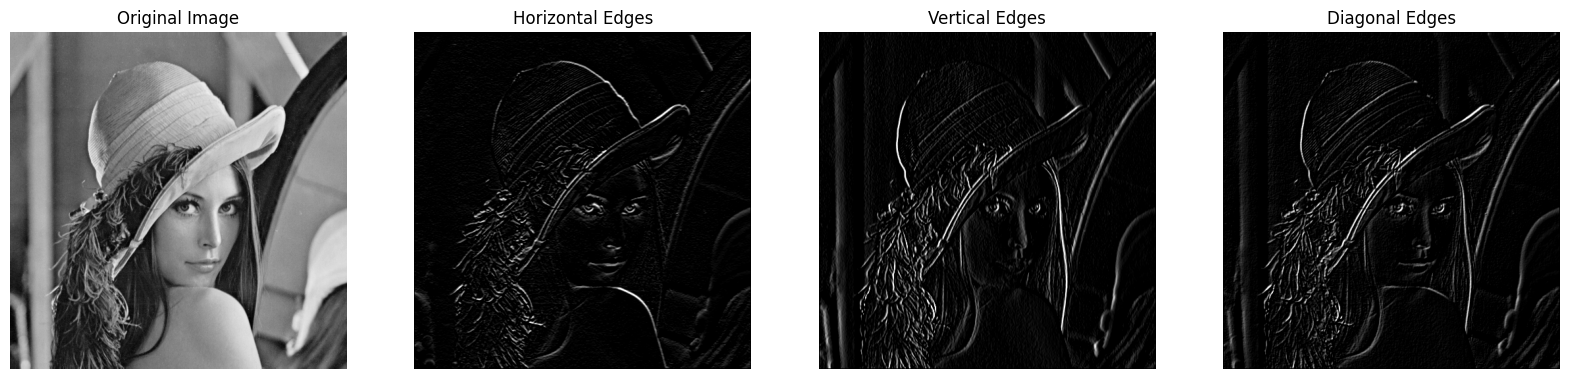

In [41]:
# 시각화
plt.figure(figsize=(20, 8))
plt.subplot(1, 4, 1)
plt.title('Original Image')
plt.imshow(image_array, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title('Horizontal Edges')
plt.imshow(horizontal_edges, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title('Vertical Edges')
plt.imshow(vertical_edges, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title('Diagonal Edges')
plt.imshow(diagonal_edges, cmap='gray')
plt.axis('off')



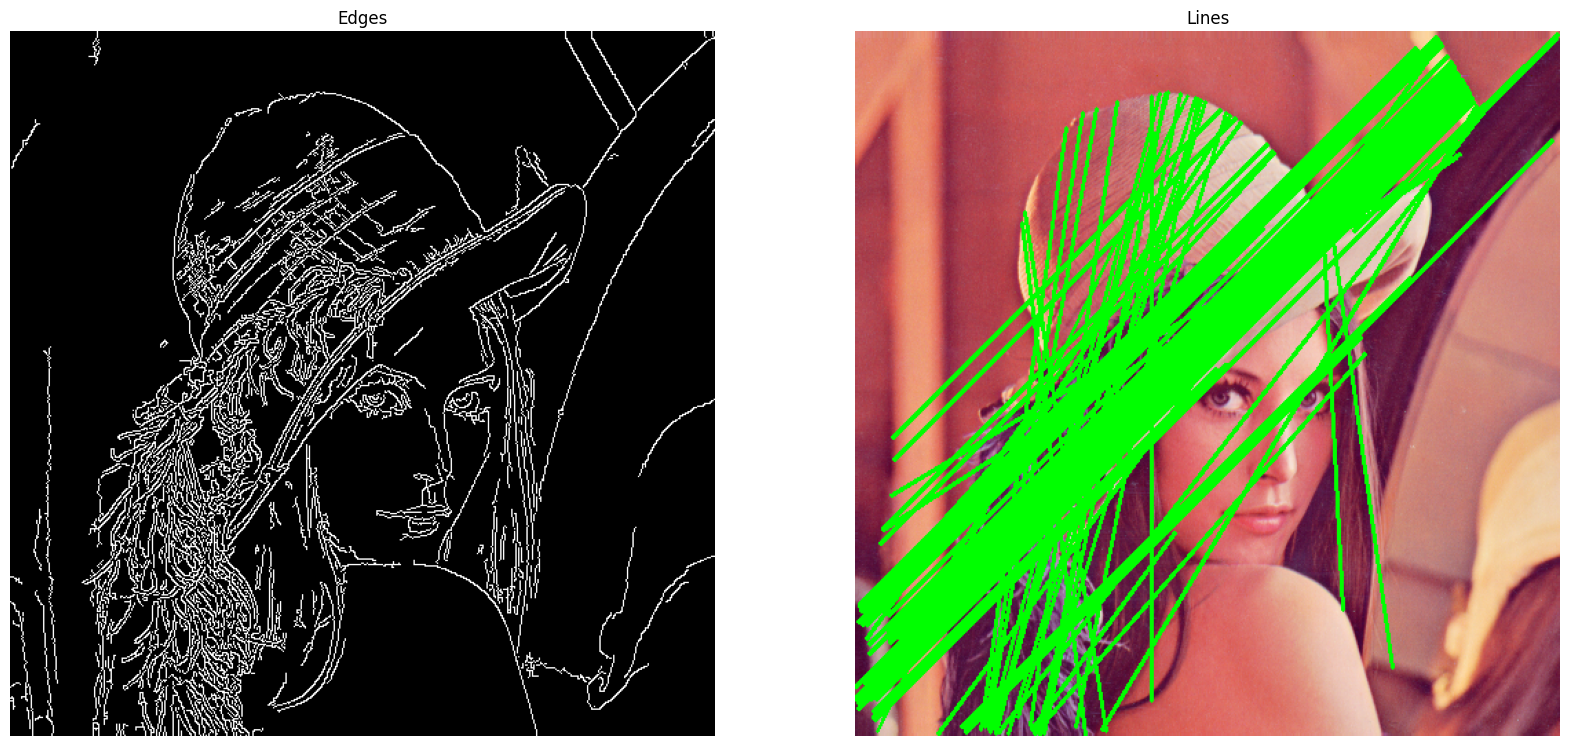

In [51]:
image = cv2.imread('./data/Lenna.png')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray_image, 50, 150)

lines = cv2.HoughLinesP(
    edges, 
    1, 
    np.pi / 180, 
    threshold=100, 
    minLineLength=50, 
    maxLineGap=100
)
# rho : 거리 해상도 (픽셀 단위)
# theta : 각도 해상도 (라디안 단위)
# threshold : 선을 검출하기 위한 임계값
# minLineLength : 검출할 선의 최소 길이
# maxLineGap : 선 사이의 최대 간격

for line in lines:
	x1, y1, x2, y2 = line[0]
	cv2.line(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(20, 15))

plt.subplot(1, 2, 1)
plt.title('Edges')
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Lines')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()